# Import Libraries

In [140]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

# Load Dataset

In [141]:
df=pd.read_csv("titanic.csv")
print("Uncleaned Titanic Data")
print(df)

Uncleaned Titanic Data
     Unnamed: 0  survived  pclass     sex   age  sibsp  parch     fare  \
0             0         0       3    male  22.0      1      0   7.2500   
1             1         1       1  female  38.0      1      0  71.2833   
2             2         1       3  female  26.0      0      0   7.9250   
3             3         1       1  female  35.0      1      0  53.1000   
4             4         0       3    male  35.0      0      0   8.0500   
..          ...       ...     ...     ...   ...    ...    ...      ...   
886         886         0       2    male  27.0      0      0  13.0000   
887         887         1       1  female  19.0      0      0  30.0000   
888         888         0       3  female   NaN      1      2  23.4500   
889         889         1       1    male  26.0      0      0  30.0000   
890         890         0       3    male  32.0      0      0   7.7500   

    embarked   class    who  adult_male deck  embark_town alive  alone  
0          S   

# Check Dataset

In [142]:
df.shape

(891, 16)

# Basic Information

In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   sex          891 non-null    object 
 4   age          714 non-null    float64
 5   sibsp        891 non-null    int64  
 6   parch        891 non-null    int64  
 7   fare         891 non-null    float64
 8   embarked     889 non-null    object 
 9   class        891 non-null    object 
 10  who          891 non-null    object 
 11  adult_male   891 non-null    bool   
 12  deck         203 non-null    object 
 13  embark_town  889 non-null    object 
 14  alive        891 non-null    object 
 15  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(5), object(7)
memory usage: 99.3+ KB


# Statistical Summary

In [144]:
df.describe()

,Unnamed: 0,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,445.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,222.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,445.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,667.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,890.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Check Missing Values

In [145]:
df.isnull().sum()

Unnamed: 0       0
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

# Filling Missing Values

In [146]:
df['age']=df['age'].fillna(df['age'].median())
print(df)

     Unnamed: 0  survived  pclass     sex   age  sibsp  parch     fare  \
0             0         0       3    male  22.0      1      0   7.2500   
1             1         1       1  female  38.0      1      0  71.2833   
2             2         1       3  female  26.0      0      0   7.9250   
3             3         1       1  female  35.0      1      0  53.1000   
4             4         0       3    male  35.0      0      0   8.0500   
..          ...       ...     ...     ...   ...    ...    ...      ...   
886         886         0       2    male  27.0      0      0  13.0000   
887         887         1       1  female  19.0      0      0  30.0000   
888         888         0       3  female  28.0      1      2  23.4500   
889         889         1       1    male  26.0      0      0  30.0000   
890         890         0       3    male  32.0      0      0   7.7500   

    embarked   class    who  adult_male deck  embark_town alive  alone  
0          S   Third    man        Tru

In [147]:
df['embarked'] = df['embarked'].fillna(
    df['embark_town'].map({
        'Southampton': 'S',
        'Cherbourg': 'C',
        'Queenstown': 'Q'
    })
)

df['embark_town'] = df['embark_town'].fillna(
    df['embarked'].map({
        'S': 'Southampton',
        'C': 'Cherbourg',
        'Q': 'Queenstown'
    })
)
print(df)

     Unnamed: 0  survived  pclass     sex   age  sibsp  parch     fare  \
0             0         0       3    male  22.0      1      0   7.2500   
1             1         1       1  female  38.0      1      0  71.2833   
2             2         1       3  female  26.0      0      0   7.9250   
3             3         1       1  female  35.0      1      0  53.1000   
4             4         0       3    male  35.0      0      0   8.0500   
..          ...       ...     ...     ...   ...    ...    ...      ...   
886         886         0       2    male  27.0      0      0  13.0000   
887         887         1       1  female  19.0      0      0  30.0000   
888         888         0       3  female  28.0      1      2  23.4500   
889         889         1       1    male  26.0      0      0  30.0000   
890         890         0       3    male  32.0      0      0   7.7500   

    embarked   class    who  adult_male deck  embark_town alive  alone  
0          S   Third    man        Tru

In [148]:
print(df[['embarked', 'embark_town']].isnull().sum())

embarked       2
embark_town    2
dtype: int64


In [149]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

df["embark_town"] = df["embark_town"].fillna(
    df["embarked"].map({
        "S": "Southampton",
        "C": "Cherbourg",
        "Q": "Queenstown"
    })
)
print(df[['embarked', 'embark_town']].isnull().sum())

embarked       0
embark_town    0
dtype: int64


In [151]:

df = df.drop(columns=['deck'])

In [152]:
expected_class = df['pclass'].map({
    1: 'First',
    2: 'Second',
    3: 'Third'
})

print(df['class'].eq(expected_class).all())

True


In [153]:

duplicates = df.duplicated(subset=df.columns.drop("Unnamed: 0"))

print(duplicates.sum())

116


In [155]:
df = df.drop_duplicates(
    subset=df.columns.drop("Unnamed: 0")
).reset_index(drop=True)


In [157]:
print(df[["age"]].to_string(formatters={"age": "{:.1f}".format}))
print(df["age"].dtype)

     age
0   22.0
1   38.0
2   26.0
3   35.0
4   35.0
5   28.0
6   54.0
7    2.0
8   27.0
9   14.0
10   4.0
11  58.0
12  20.0
13  39.0
14  14.0
15  55.0
16   2.0
17  28.0
18  31.0
19  28.0
20  35.0
21  34.0
22  15.0
23  28.0
24   8.0
25  38.0
26  28.0
27  19.0
28  28.0
29  28.0
30  40.0
31  28.0
32  28.0
33  66.0
34  28.0
35  42.0
36  28.0
37  21.0
38  18.0
39  14.0
40  40.0
41  27.0
42  28.0
43   3.0
44  19.0
45  28.0
46  28.0
47  28.0
48  18.0
49   7.0
50  21.0
51  49.0
52  29.0
53  65.0
54  21.0
55  28.5
56   5.0
57  11.0
58  22.0
59  38.0
60  45.0
61   4.0
62  28.0
63  28.0
64  29.0
65  19.0
66  17.0
67  26.0
68  32.0
69  16.0
70  21.0
71  26.0
72  32.0
73  25.0
74   0.8
75  30.0
76  22.0
77  29.0
78  28.0
79  28.0
80  17.0
81  33.0
82  16.0
83  23.0
84  24.0
85  29.0
86  20.0
87  46.0
88  26.0
89  59.0
90  71.0
91  23.0
92  34.0
93  34.0
94  28.0
95  21.0
96  33.0
97  37.0
98  21.0
99  28.0
100 38.0
101 28.0
102 47.0
103 14.5
104 22.0
105 20.0
106 17.0
107 21.0
108 70.5
109 29.0
1

In [158]:
print((df.loc[df["survived"] == 0, "alive"] == "no").all())
print((df.loc[df["survived"] == 1, "alive"] == "yes").all())

True
True


In [159]:
print((df.loc[df["embarked"] == "S", "embark_town"] == "Southampton").all())
print((df.loc[df["embarked"] == "C", "embark_town"] == "Cherbourg").all())
print((df.loc[df["embarked"] == "Q", "embark_town"] == "Queenstown").all())

True
True
True


In [160]:
print(
    df["alone"].eq(
        (df["sibsp"] == 0) & (df["parch"] == 0)
    ).all()
)

True


In [161]:
df.isnull().sum()

Unnamed: 0     0
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [162]:
df.to_csv("Cleaned_Titanic_Data.csv",index=False)

# Cleaned Titanic Data Visualization

In [163]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Cleaned_Titanic_Data.csv",index_col=0)

print(df.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')


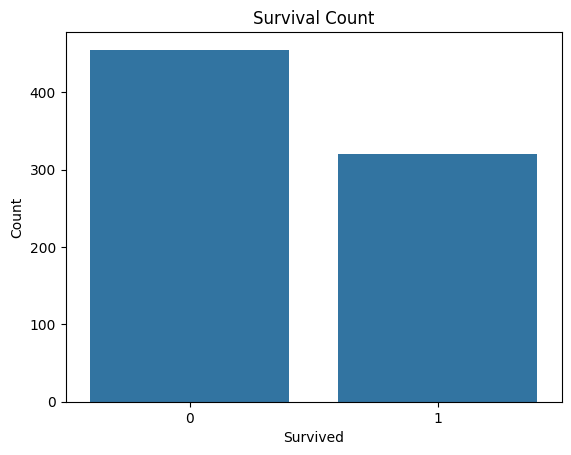

In [164]:
sns.countplot(data=df, x="survived")
plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

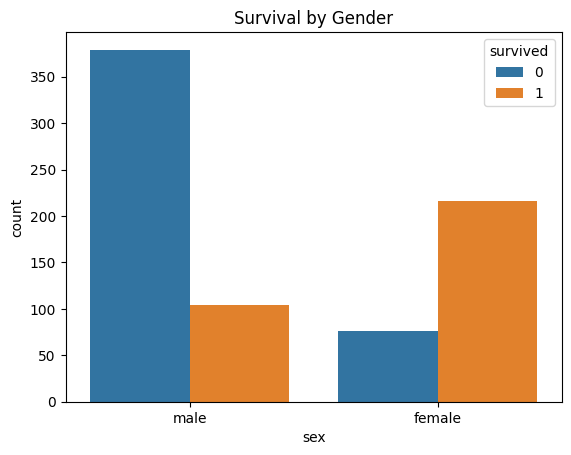

In [165]:
sns.countplot(data=df, x="sex", hue="survived")
plt.title("Survival by Gender")
plt.show()

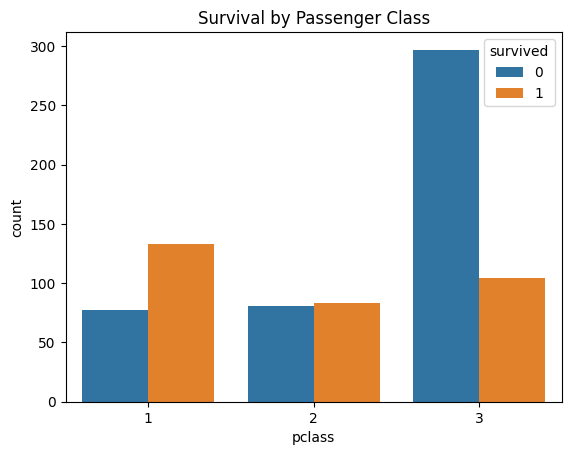

In [166]:
sns.countplot(data=df, x="pclass", hue="survived")
plt.title("Survival by Passenger Class")
plt.show()

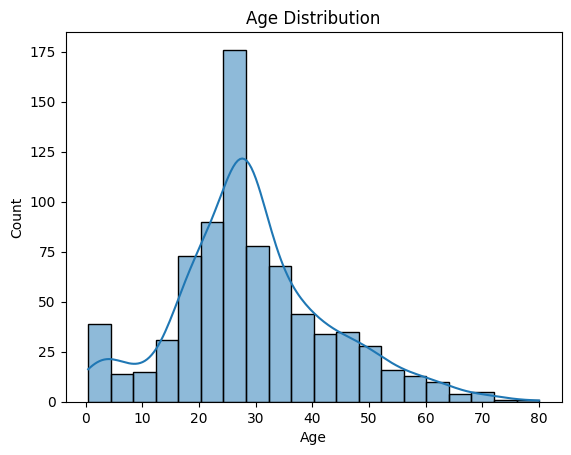

In [167]:
sns.histplot(data=df, x="age", kde=True,bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

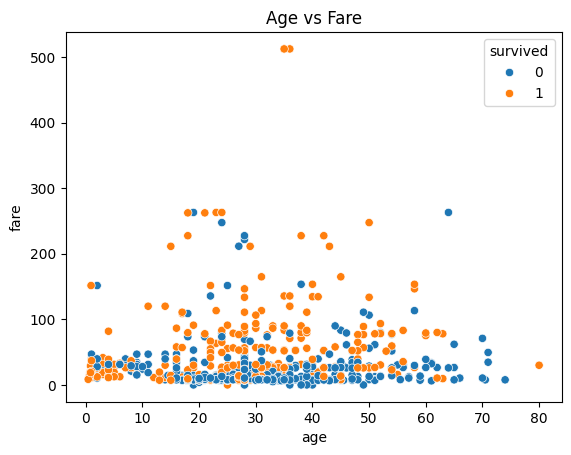

In [168]:
sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived"
)

plt.title("Age vs Fare")
plt.show()

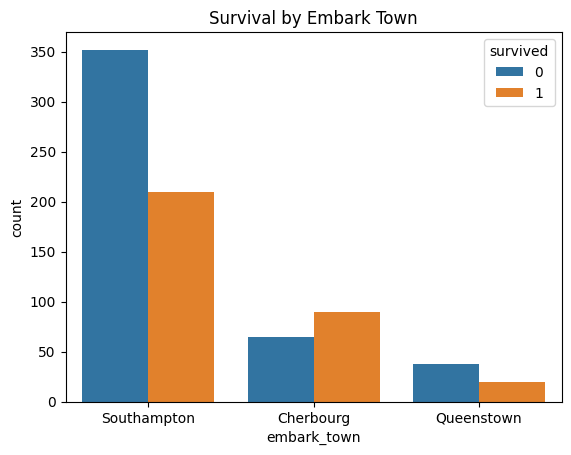

In [169]:
sns.countplot(data=df, x="embark_town", hue="survived")
plt.title("Survival by Embark Town")
plt.show()

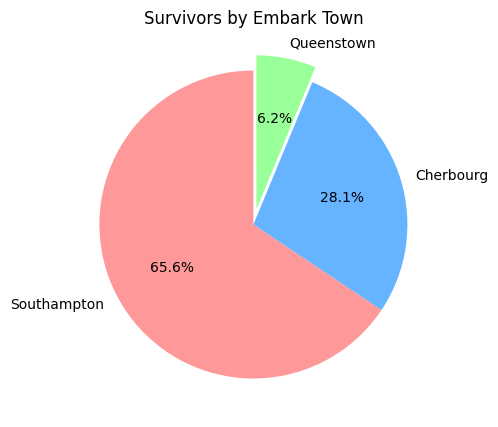

In [178]:
survived = df[df["survived"] == 1]["embark_town"].value_counts()
explode=[0,0,0.1]

plt.figure(figsize=(5,5))
plt.pie(survived,labels=survived.index,autopct='%1.1f%%',startangle=90,colors=['#ff9999','#66b3ff','#99ff99'],explode=explode)
plt.title("Survivors by Embark Town")
plt.show()


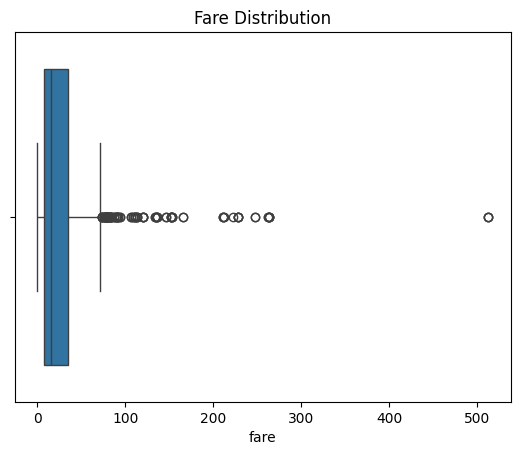

In [171]:
sns.boxplot(data=df, x="fare")
plt.title("Fare Distribution")
plt.show()

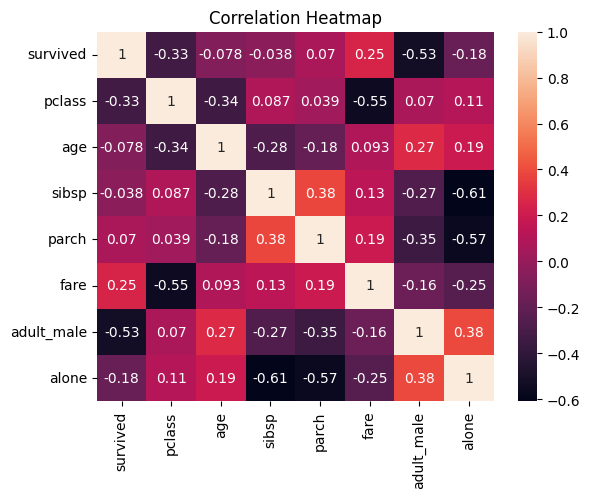

In [172]:
correlation = df.corr(numeric_only=True)

sns.heatmap(correlation,annot=True)

plt.title("Correlation Heatmap")
plt.show()

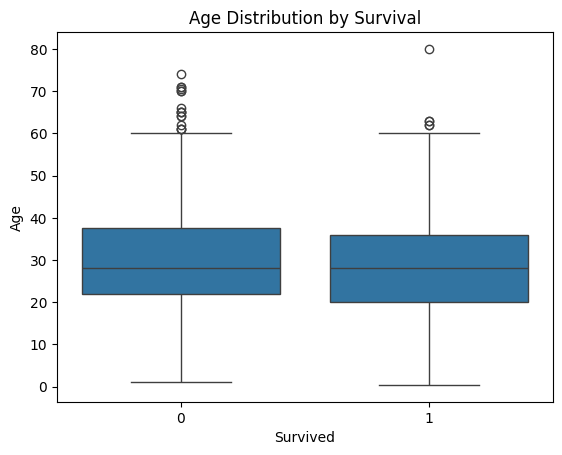

In [173]:
sns.boxplot(
    data=df,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Age")
plt.show()

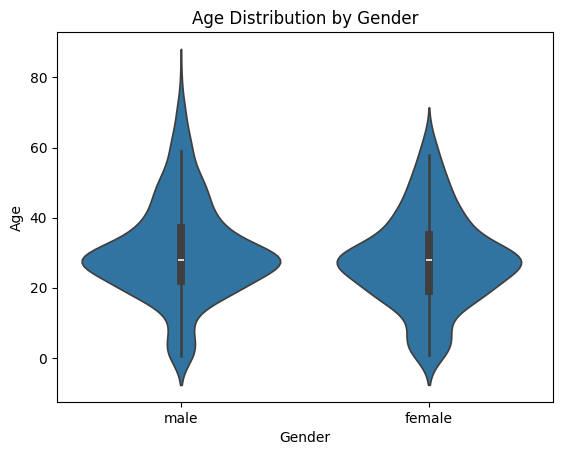

In [174]:
sns.violinplot(
    data=df,
    x="sex",
    y="age"
)

plt.title("Age Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Age")
plt.show()

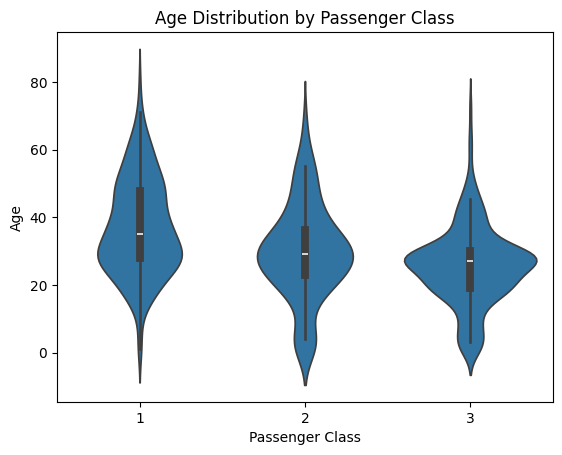

In [175]:
sns.violinplot(
    data=df,
    x="pclass",
    y="age"
)

plt.title("Age Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.show()

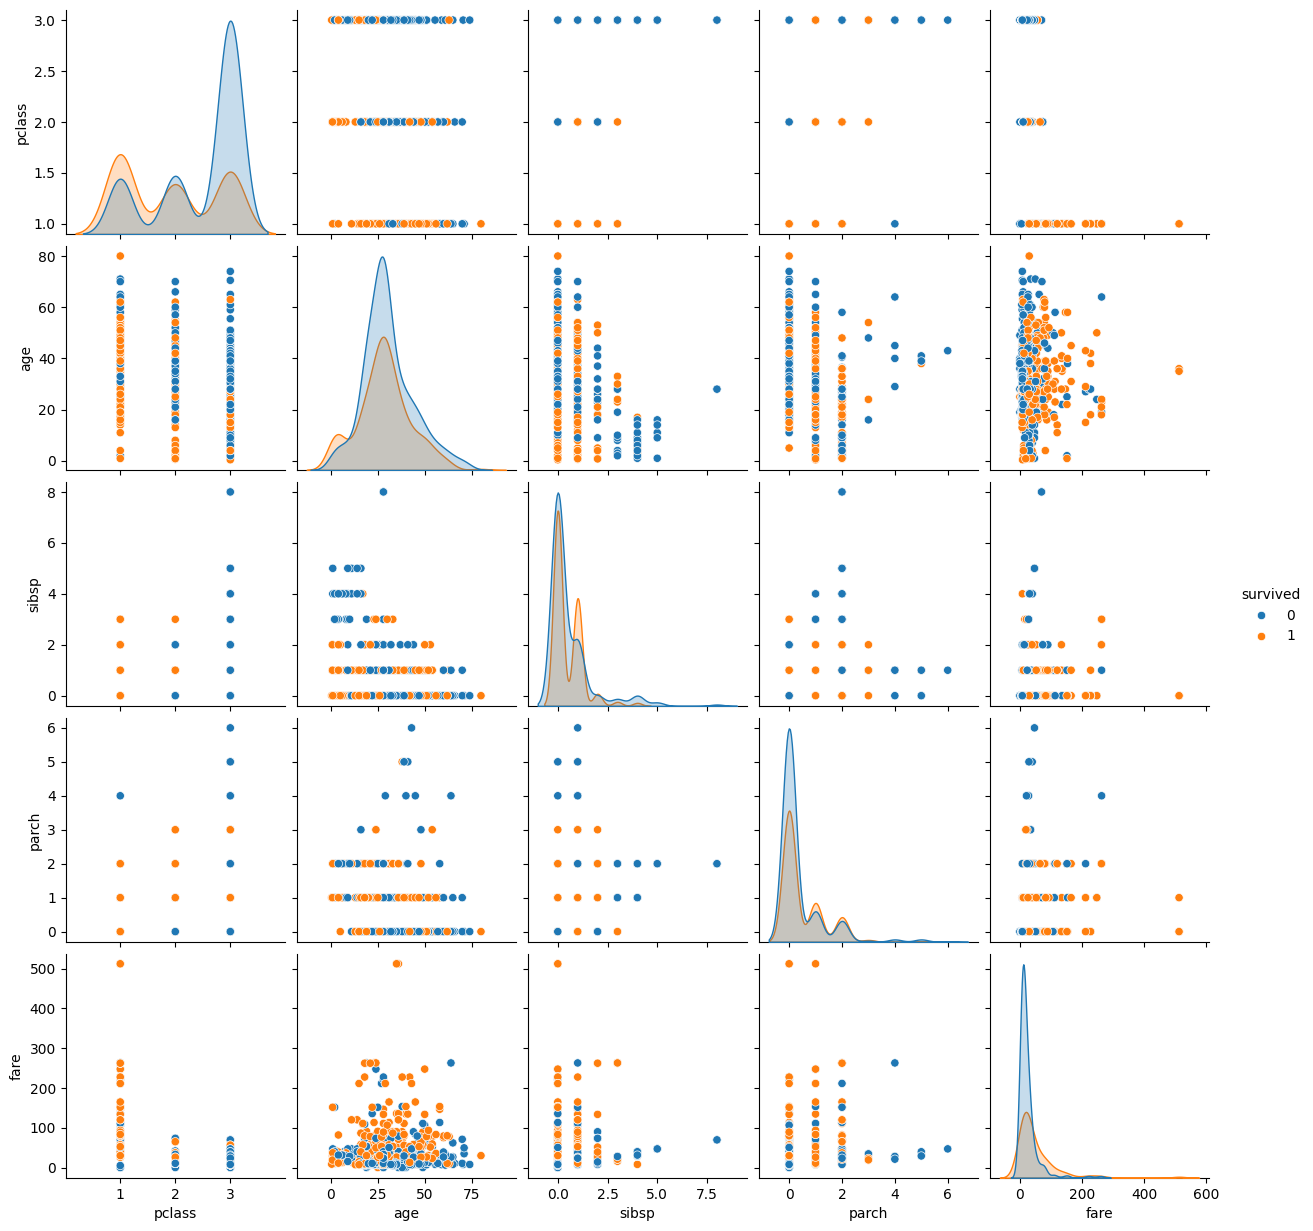

In [176]:
sns.pairplot(
    df[["survived", "pclass", "age", "sibsp", "parch", "fare"]],
    hue="survived"
)

plt.show()

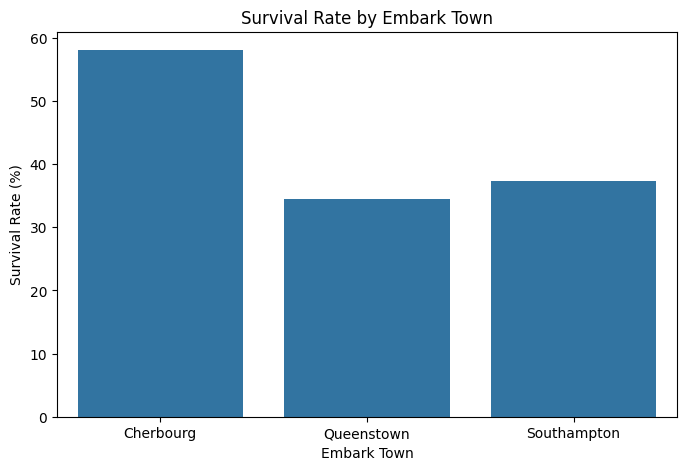

In [177]:
survival_rate = df.groupby("embark_town")["survived"].mean() * 100

plt.figure(figsize=(8, 5))

sns.barplot(
    x=survival_rate.index,
    y=survival_rate.values
)

plt.title("Survival Rate by Embark Town")
plt.xlabel("Embark Town")
plt.ylabel("Survival Rate (%)")

plt.show()



# Cherbourg: around 55.5% passenger survived — high survival rate
# Queenstown: around 39% passenger survived 
# Southampton: around 34% passenger survived